In [16]:
"""
(28751) Eggl orbit determination test using the standalone native C++ bindings.

This is a native-C++-enhanced, OpenAI's GPT-5.6 Luna recreation of:
    https://rahil-makadia.github.io/grss/tests/python/fit/eggl.html

Requirements
------------
- A working GRSS Python installation.
- The standalone pybind11 extension produced from grss_full_bindings.cpp,
  importable as ``grss_full``.

The existing GRSS Python orbit-fitting workflow is retained.  The new
``grss_full`` module is used explicitly for several computations so that the
C++ implementation is visibly exercised from Python.
"""

from __future__ import annotations

import numpy as np

from grss import fit

# -----------------------------------------------------------------------------
# NEW: standalone native C++ binding module.
# The extension is built from grss_full_bindings.cpp and exposes GRSS's C++
# orbital mechanics / numerical routines directly to Python.
# -----------------------------------------------------------------------------
try:
    import grss_full as cpp
except ImportError as exc:  # pragma: no cover - depends on the local build
    raise ImportError(
        "Could not import grss_full. Build the standalone native extension "
        "from grss_full_bindings.cpp first, then rerun this example."
    ) from exc

np.set_printoptions(precision=16, linewidth=np.inf, suppress=False)


BODY_ID = "28751"
DE_KERNEL = 440
ADD_GAIA_OBS = True


# -----------------------------------------------------------------------------
# Helper functions that make the C++/Python boundary visible in the output.
# -----------------------------------------------------------------------------
def _print_native_header(title: str) -> None:
    print("\n" + "=" * 78)
    print(f"NATIVE C++ -> PYTHON: {title}")
    print("=" * 78)


def _as_cpp_list(array_like) -> list[float]:
    """Convert a NumPy vector into the std::vector-compatible Python form."""
    return np.asarray(array_like, dtype=float).tolist()




# (28751) Eggl orbit determination test

This follows the published Eggl example, while making the new native C++
bindings visible in the calculation path.



## Let's start by importing the necessary libraries

``fit`` is still the high-level GRSS orbit-fitting interface.  ``cpp`` is
the new standalone pybind11 module that calls the native C++ implementation.



In [17]:
body_id = BODY_ID
print(f"Target: ({body_id}) Eggl")
print(f"Native C++ binding: {cpp.__name__}")




Target: (28751) Eggl
Native C++ binding: grss_full


## We'll then retrieve the cometary state of the asteroid

The JPL SBDB values are returned in the same cometary-element convention used
by the reference GRSS example: ``[e, q, tp, om, w, i]`` after the epoch ``t``.



In [18]:
init_sol, init_cov, nongrav_info = fit.get_sbdb_info(body_id)
print("Initial SBDB cometary solution:")
print(init_sol)
de_kernel = DE_KERNEL




Initial SBDB cometary solution:
{'t': 58309.0, 'e': 0.1137178986372383, 'q': 2.234436451171969, 'tp': 57939.289503020234, 'om': 4.821677021020488, 'w': 0.8614196233789506, 'i': 0.030476970077613297}


## Native C++ orbital-state conversion

Here the exact SBDB cometary state is passed to the newly bound C++ routine
``cometary_to_cartesian``.  We then call the native C++ inverse conversion
``cartesian_to_cometary`` and use the native C++ vector routines ``vsub`` and
``vnorm`` to measure the round-trip error.

These are **not** Python reimplementations: the calls below enter C++ through
pybind11 and execute the original GRSS C++ orbital-mechanics functions.



In [19]:
_initial_epoch = float(init_sol["t"])
_initial_cometary = np.asarray(
    [init_sol[k] for k in ("e", "q", "tp", "om", "w", "i")],
    dtype=float,
)

_print_native_header("cometary -> Cartesian -> cometary")

# NATIVE C++ BOUND CALL: GRSS C++ cometary_to_cartesian().
_initial_cartesian = np.asarray(
    cpp.cometary_to_cartesian(
        _initial_epoch,
        _as_cpp_list(_initial_cometary),
    ),
    dtype=float,
)

# NATIVE C++ BOUND CALL: GRSS C++ cartesian_to_cometary().
_initial_cometary_recovered = np.asarray(
    cpp.cartesian_to_cometary(
        _initial_epoch,
        _as_cpp_list(_initial_cartesian),
    ),
    dtype=float,
)

# The perihelion-passage epoch can differ by an integer orbital period after an
# element conversion. Therefore the strict round-trip check is done on the
# Cartesian state via the native C++ Keplerian conversion pair.
# NATIVE C++ BOUND CALL: Cartesian -> Keplerian in C++.
_initial_keplerian = np.asarray(
    cpp.cartesian_to_keplerian(_as_cpp_list(_initial_cartesian)),
    dtype=float,
)

# NATIVE C++ BOUND CALL: Keplerian -> Cartesian in C++.
_initial_cartesian_roundtrip = np.asarray(
    cpp.keplerian_to_cartesian(_as_cpp_list(_initial_keplerian)),
    dtype=float,
)

# NATIVE C++ BOUND CALL: C++ vector subtraction and Euclidean norm.
_initial_roundtrip_error = cpp.vnorm(
    cpp.vsub(
        _as_cpp_list(_initial_cartesian_roundtrip),
        _as_cpp_list(_initial_cartesian),
    )
)

print("Initial Cartesian state [AU, AU/day]:")
print(_initial_cartesian)
print("Recovered cometary state from native C++:")
print(_initial_cometary_recovered)
print("Native C++ Cartesian round-trip error:", _initial_roundtrip_error)





NATIVE C++ -> PYTHON: cometary -> Cartesian -> cometary
Initial Cartesian state [AU, AU/day]:
[ 8.9416509400351296e-01  2.3968995191200020e+00  3.5067353042123432e-02 -9.5117210780715604e-03  4.8371484363051399e-03 -2.7216386873612683e-04]
Recovered cometary state from native C++:
[1.1371789863723816e-01 2.2344364511719692e+00 5.7939289503020234e+04 4.8216770210204878e+00 8.6141962337895028e-01 3.0476970077612051e-02]
Native C++ Cartesian round-trip error: 1.7990170086618473e-15


## Native C++ time conversion and angle conversion

The high-level fit code uses MJD/TDB, while the C++ propagation layer also
works with SPICE ephemeris time.  The calls below exercise the native C++ time
conversion functions directly.



In [20]:
_print_native_header("MJD <-> SPICE ephemeris time")

# NATIVE C++ BOUND CALL: MJD -> SPICE ET.
_initial_et = cpp.mjd_to_et(_initial_epoch)

# NATIVE C++ BOUND CALL: SPICE ET -> MJD.
_initial_epoch_roundtrip = cpp.et_to_mjd(_initial_et)

# NATIVE C++ BOUND CALL: C++ angle conversion from radians to degrees.
_initial_inclination_deg = cpp.rad_to_deg(float(init_sol["i"]))

print(f"Initial epoch MJD/TDB: {_initial_epoch:.12f}")
print(f"Native C++ ET [s past J2000]: {_initial_et:.6f}")
print(f"Native C++ MJD round-trip: {_initial_epoch_roundtrip:.12f}")
print(f"Initial inclination: {_initial_inclination_deg:.12f} deg")

np.testing.assert_allclose(_initial_epoch_roundtrip, _initial_epoch, rtol=0.0, atol=1e-12)
assert _initial_roundtrip_error < 1e-9





NATIVE C++ -> PYTHON: MJD <-> SPICE ephemeris time
Initial epoch MJD/TDB: 58309.000000000000
Native C++ ET [s past J2000]: 584452800.000000
Native C++ MJD round-trip: 58309.000000000000
Initial inclination: 1.746201757794 deg


## Next, we'll retrieve the observations from different sources

This remains the same high-level GRSS workflow as the reference example:
MPC optical astrometry, radar observations, and optionally Gaia.



In [21]:
add_gaia_obs = ADD_GAIA_OBS
optical_obs_file = None
t_min_tdb = None
t_max_tdb = None
debias_lowres = True
deweight = True
eliminate = False
num_obs_per_night = 4
verbose = True

obs_df = fit.get_optical_obs(
    body_id,
    optical_obs_file,
    t_min_tdb,
    t_max_tdb,
    debias_lowres,
    deweight,
    eliminate,
    num_obs_per_night,
    verbose,
)
obs_df = fit.add_radar_obs(obs_df, t_min_tdb, t_max_tdb, verbose)
if add_gaia_obs:
    gaia_dr = "gaiafpr"
    obs_df = fit.add_gaia_obs(obs_df, t_min_tdb, t_max_tdb, gaia_dr, verbose)




Read in 1863 observations from the MPC.
	Filtered to 1863 observations that satisfy the time range and accepted observatory constraints.
Applying Eggl et al. (2020) debiasing scheme to the observations.
	Unknown star catalog: GSC
	Unknown star catalog: UNK
	No debiasing needed for 957 observations.
	Debiased 891 observations.
	No bias information for 15 observations.
Applying Vereš et al. (2017) weighting scheme to the observations.
	Using 1573 CCD observations with station-specific weight rules.
Applying sqrt(N/4) deweighting scheme.
	Deweighted 353 observations.
Read in 273 Gaia observations from gaiafpr
	Filtered to 273 observations that satisfy the time range constraints.


## All we need to do now is initialize the OD simulation and run the filter



In [22]:
n_iter_max = 10
fit_sim = fit.FitSimulation(
    init_sol,
    obs_df,
    init_cov,
    n_iter_max=n_iter_max,
    de_kernel=de_kernel,
    nongrav_info=nongrav_info,
)

fit_sim.filter_lsq()




Iteration		Unweighted RMS		Weighted RMS 		Chi-squared		Reduced Chi-squared
1			 0.366			 0.520			 1157.347			 0.271
2			 0.366			 0.520			 1156.961			 0.271
Converged without rejecting outliers. Starting outlier rejection now...
3			 0.358			 0.505			 1090.402			 0.256
4			 0.358			 0.505			 1090.044			 0.256
Converged after rejecting outliers. Rejected 5 out of 2136 optical observations.


## Let's print some summary statistics and plot some results



Summary of the orbit fit calculations after postfit pass:
RMS unweighted: 0.35771008948287375
RMS weighted: 0.5051337591388704
chi-squared: 1090.0440096641855
reduced chi-squared: 0.2561193631729759
square root of reduced chi-squared: 0.5060823679728191
--------------------------------------------------------------
Solution Time: MJD 58309.000 TDB = 2018-07-10 00:00:00.000 TDB
Solution Observation Arc: 11366.13 days (31.12 years)
--------------------------------------------------------------
Fitted Variable		Initial Value			Uncertainty			Fitted Value			Uncertainty			Change				Change (sigma)
e			1.13717898637e-01		2.58776011418e-09		1.13717898991e-01		2.59123030263e-09		+3.54173232409e-10		+0.137
q			2.23443645117e+00		5.15331085332e-09		2.23443645085e+00		5.15288313817e-09		-3.25069304807e-10		-0.063
tp			5.79392895030e+04		3.09738494834e-06		5.79392895030e+04		3.09545126573e-06		+1.55923771672e-08		+0.005
om			2.76261743480e+02		2.72651026590e-06		2.76261743596e+02		2.72509754228e-06	

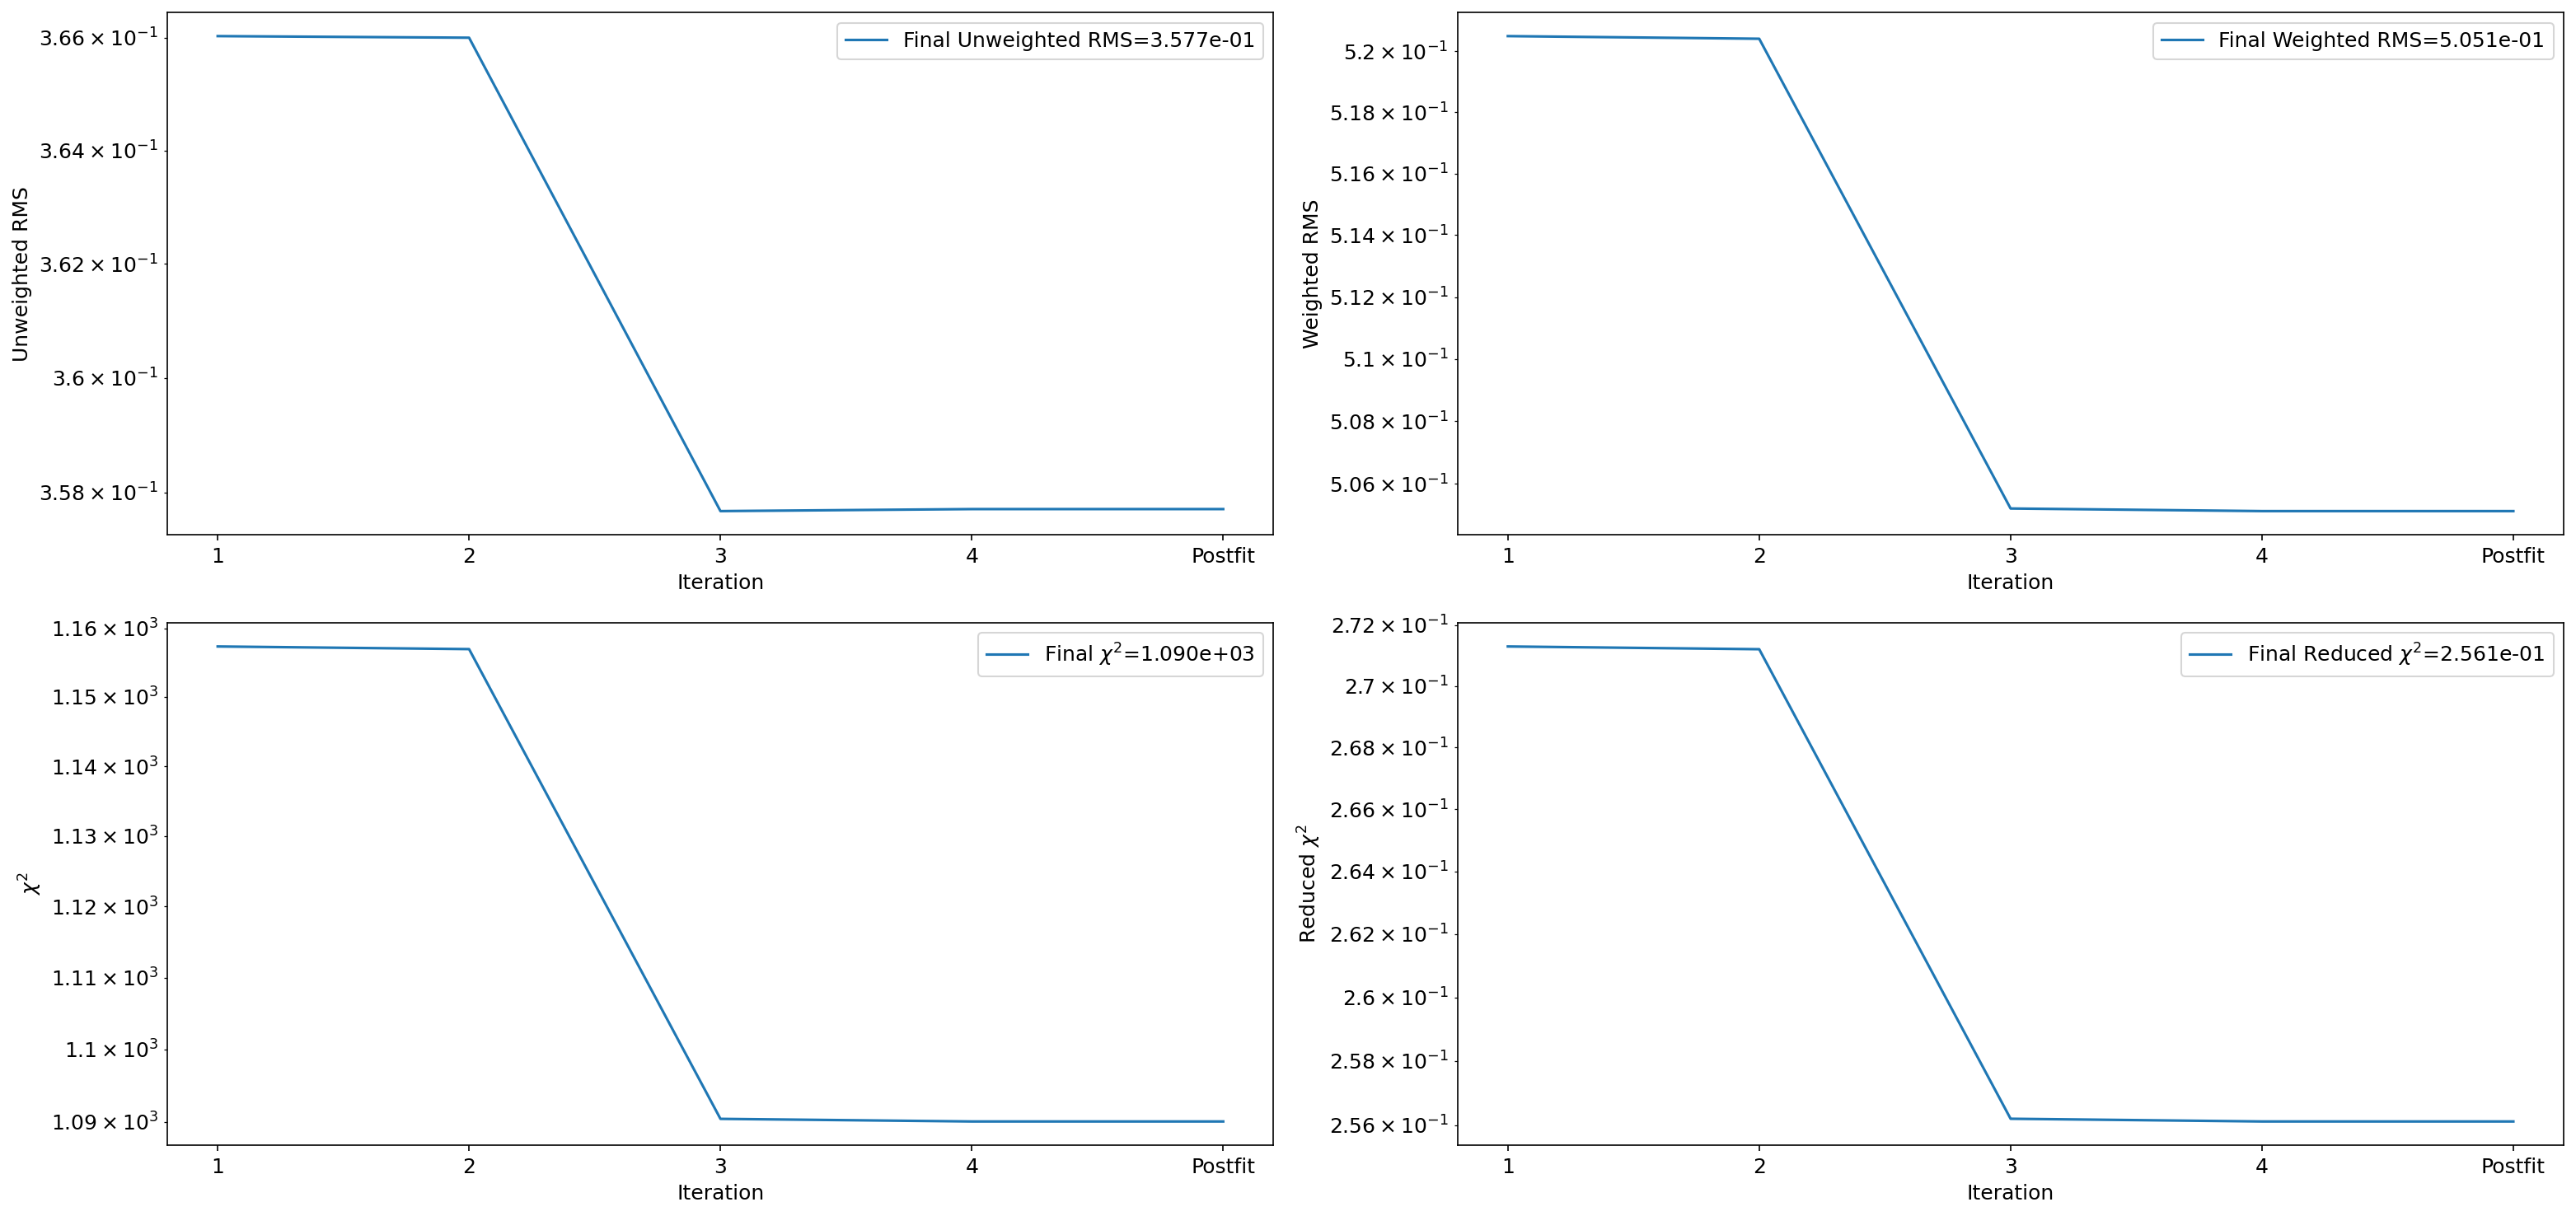

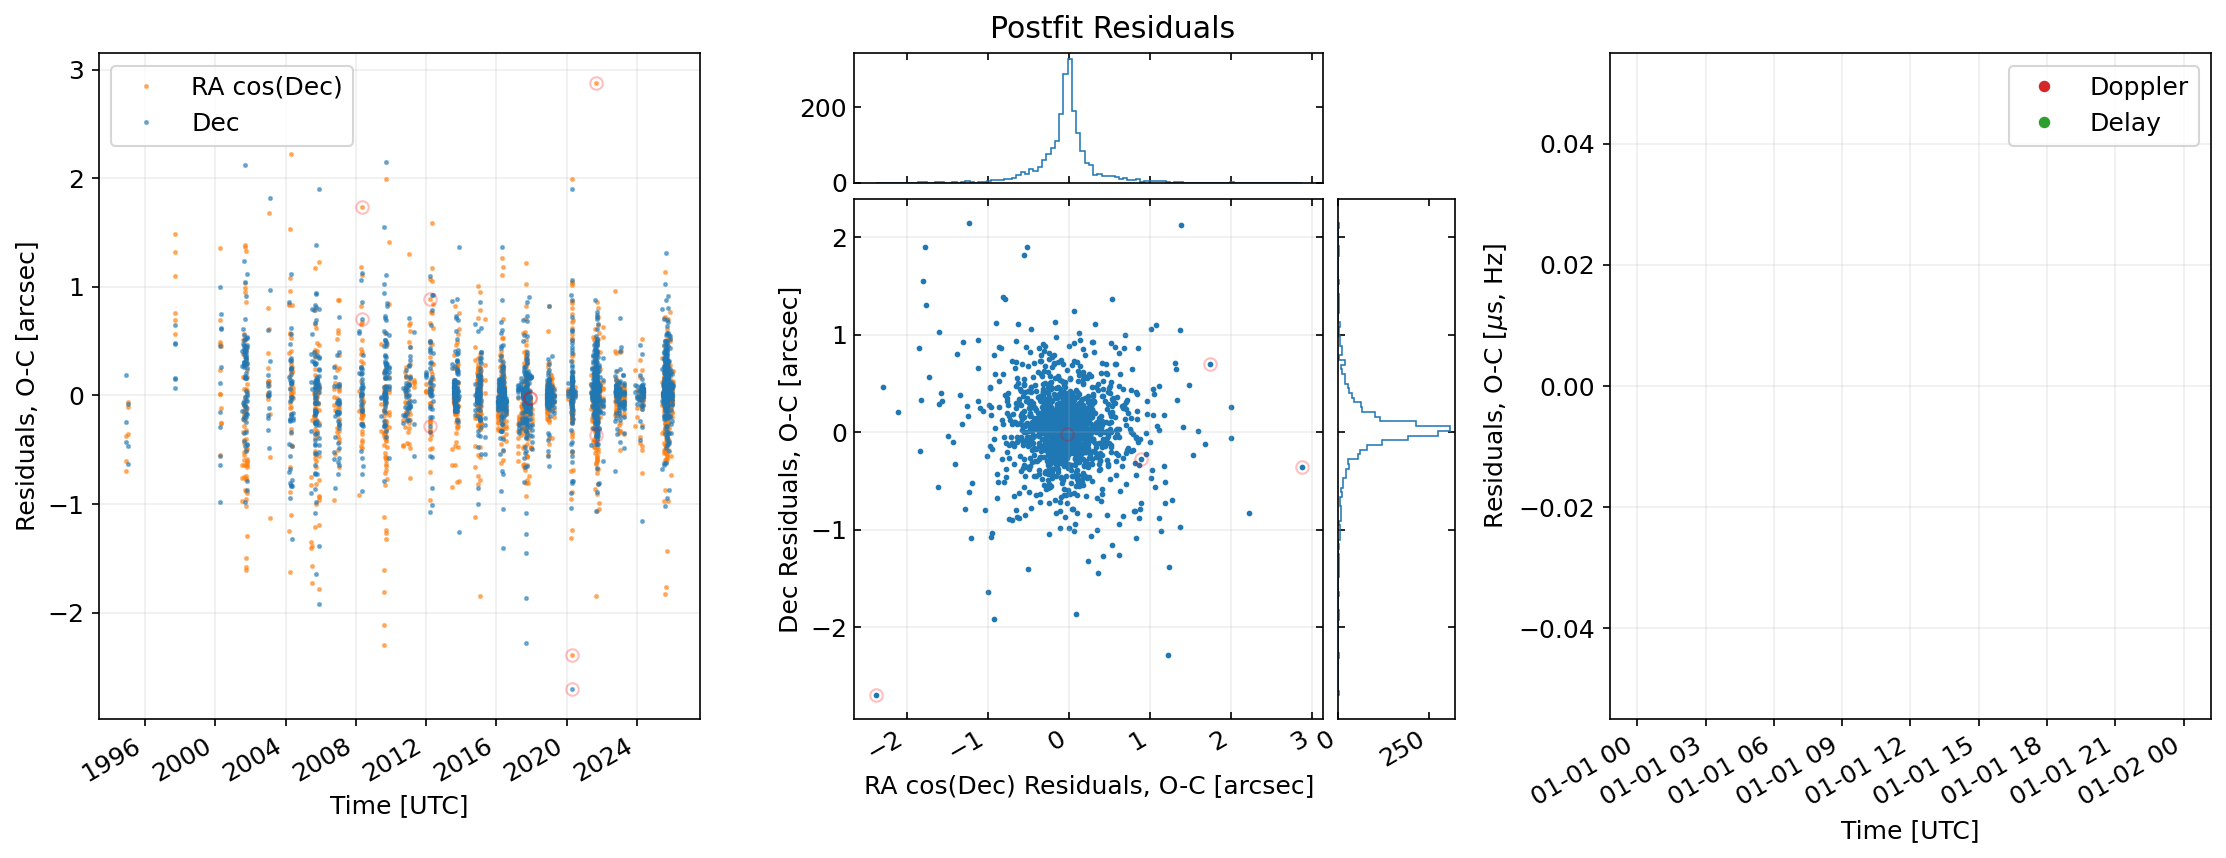

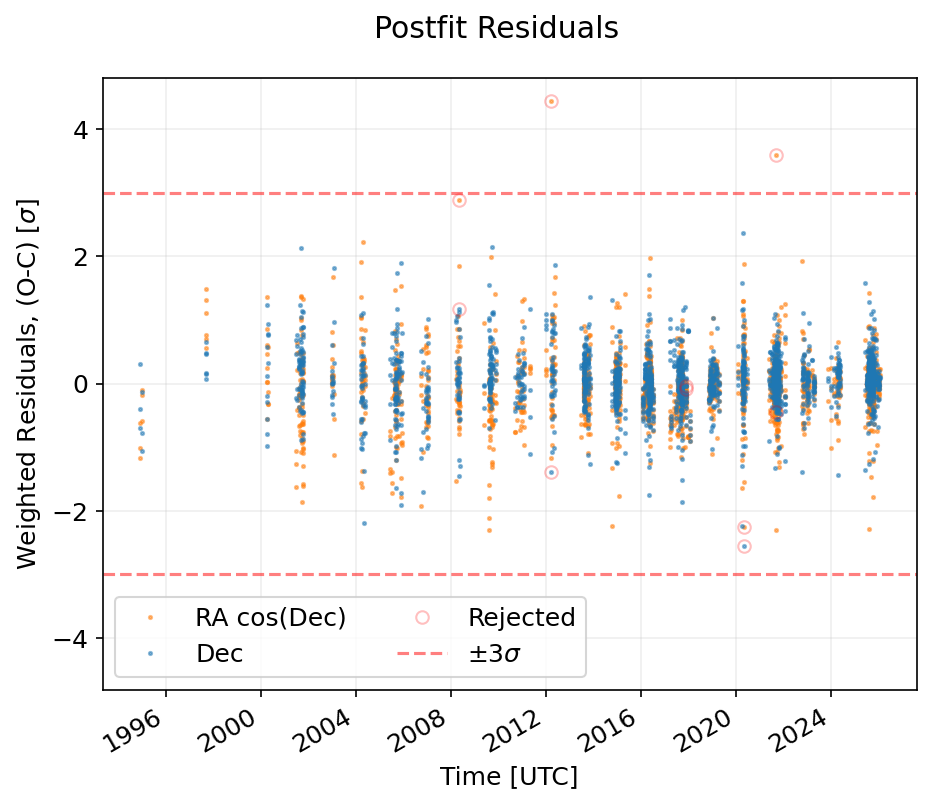

In [23]:
fit_sim.print_summary()
fit_sim.plot_summary(auto_close=True)
fit_sim.iters[-1].plot_iteration_summary(
    title="Postfit Residuals",
    auto_close=True,
)




## Native C++ verification of the fitted orbit

We now take the *fitted* cometary solution produced by the Python fitting
layer and send it through the same native C++ conversion pipeline.

This gives a useful end-to-end check:

``JPL SBDB -> Python fit -> fitted cometary state -> native C++ Cartesian state``



In [24]:
_final_cometary = np.asarray(
    [fit_sim.x_nom[k] for k in ("e", "q", "tp", "om", "w", "i")],
    dtype=float,
)

_print_native_header("fitted orbit -> Cartesian")

# NATIVE C++ BOUND CALL: use the final fitted orbit with the original C++
# orbital-elements conversion routine.
_final_cartesian = np.asarray(
    cpp.cometary_to_cartesian(
        float(fit_sim.t_sol),
        _as_cpp_list(_final_cometary),
    ),
    dtype=float,
)

# NATIVE C++ BOUND CALL: Cartesian -> cometary in C++.
_final_cometary_recovered = np.asarray(
    cpp.cartesian_to_cometary(
        float(fit_sim.t_sol),
        _as_cpp_list(_final_cartesian),
    ),
    dtype=float,
)

# NATIVE C++ BOUND CALL: verify the fitted Cartesian state by going through
# Keplerian elements and back, all inside the native C++ element routines.
_final_keplerian = np.asarray(
    cpp.cartesian_to_keplerian(_as_cpp_list(_final_cartesian)),
    dtype=float,
)
_final_cartesian_roundtrip = np.asarray(
    cpp.keplerian_to_cartesian(_as_cpp_list(_final_keplerian)),
    dtype=float,
)

# NATIVE C++ BOUND CALL: quantify the round-trip error using C++ vector math.
_final_roundtrip_error = cpp.vnorm(
    cpp.vsub(
        _as_cpp_list(_final_cartesian_roundtrip),
        _as_cpp_list(_final_cartesian),
    )
)

print("Fitted cometary state [e, q, tp, om, w, i]:")
print(_final_cometary)
print("Fitted Cartesian state [AU, AU/day]:")
print(_final_cartesian)
print("Recovered cometary state from native C++:")
print(_final_cometary_recovered)
print("Native C++ Cartesian round-trip error:", _final_roundtrip_error)

assert _final_roundtrip_error < 1e-10





NATIVE C++ -> PYTHON: fitted orbit -> Cartesian
Fitted cometary state [e, q, tp, om, w, i]:
[1.1371789899141153e-01 2.2344364508468999e+00 5.7939289503035827e+04 4.8216770230589940e+00 8.6141962137059125e-01 3.0476970062510947e-02]
Fitted Cartesian state [AU, AU/day]:
[ 8.9416509407480216e-01  2.3968995198136382e+00  3.5067353171212276e-02 -9.5117210753728424e-03  4.8371484384058172e-03 -2.7216386814911495e-04]
Recovered cometary state from native C++:
[1.1371789899141141e-01 2.2344364508469003e+00 5.7939289503035827e+04 4.8216770230589940e+00 8.6141962137059080e-01 3.0476970062510201e-02]
Native C++ Cartesian round-trip error: 1.3702262452398643e-15


## Finally, compare the GRSS fit with the JPL SBDB solution

The original page uses ``fit.get_similarity_stats`` for this check.  Here we
retain that check and additionally compute the two Mahalanobis distances using
the newly bound native C++ ``mat_inv`` function.



In [25]:
mean_0 = np.asarray(list(init_sol.values())[1:], dtype=float)
cov_0 = np.asarray(init_cov, dtype=float)
mean_f = np.asarray(list(fit_sim.x_nom.values()), dtype=float)
cov_f = np.asarray(fit_sim.covariance, dtype=float)

maha_dist_f, maha_dist_0, bhattacharya, bhatt_coeff = fit.get_similarity_stats(
    mean_0,
    cov_0,
    mean_f,
    cov_f,
)

print(f"Mahalanobis distance between JPL and GRSS solution: {maha_dist_f:0.2f}")
print(f"Mahalanobis distance between GRSS and JPL solution: {maha_dist_0:0.2f}")
print(f"Bhattacharyya distance between JPL and GRSS solution: {bhattacharya:0.4f}")
print(f"Bhattacharyya coefficient between JPL and GRSS solution: {bhatt_coeff:0.4f}")

_print_native_header("native C++ covariance inversion")

# The raw covariance matrices combine position and velocity components with
# very different physical scales. GRSS's native LU routine uses an absolute
# pivot tolerance, so directly inverting the raw matrix can classify a valid,
# extremely ill-conditioned covariance as "degenerate".
#
# Normalize each covariance to a dimensionless correlation matrix first:
#     C = D R D, where D = diag(sqrt(diag(C))).
# Then C^{-1} = D^{-1} R^{-1} D^{-1}.
# This is mathematically equivalent, but much better conditioned for the
# native LU implementation.
def _native_covariance_inverse(covariance):
    sigma = np.sqrt(np.diag(covariance))
    if np.any(~np.isfinite(sigma)) or np.any(sigma <= 0.0):
        raise ValueError("Covariance has non-positive or non-finite diagonal entries")

    dinv = np.diag(1.0 / sigma)
    correlation = dinv @ covariance @ dinv

    # NATIVE C++ BOUND CALL: invert the dimensionless 6x6 correlation matrix
    # with GRSS's actual C++ LU-based matrix inverse.
    correlation_inv_cpp = np.asarray(cpp.mat_inv(correlation.tolist()), dtype=float)

    # Transform the native inverse back to the original covariance units.
    return dinv @ correlation_inv_cpp @ dinv

cov_0_inv_cpp = _native_covariance_inverse(cov_0)
cov_f_inv_cpp = _native_covariance_inverse(cov_f)

delta = mean_0 - mean_f

# The first distance uses the initial/JPL covariance.
maha_dist_f_cpp = float(np.sqrt(delta @ cov_0_inv_cpp @ delta))
# The second distance uses the final/GRSS covariance.
maha_dist_0_cpp = float(np.sqrt(delta @ cov_f_inv_cpp @ delta))

print(f"Native C++ Mahalanobis distance (JPL covariance): {maha_dist_f_cpp:0.12f}")
print(f"Native C++ Mahalanobis distance (GRSS covariance): {maha_dist_0_cpp:0.12f}")
print(
    "Difference from high-level Python calculation:",
    abs(maha_dist_f_cpp - maha_dist_f),
    abs(maha_dist_0_cpp - maha_dist_0),
)

np.testing.assert_allclose(maha_dist_f_cpp, maha_dist_f, rtol=1e-8, atol=1e-8)
np.testing.assert_allclose(maha_dist_0_cpp, maha_dist_0, rtol=1e-8, atol=1e-8)

# Same statistical consistency assertions as the published example.
assert maha_dist_f < 5.0
assert maha_dist_0 < 5.0
assert bhattacharya < 0.10
assert bhatt_coeff > 0.90

print("\nEggl example completed successfully, including native C++ checks.")


Mahalanobis distance between JPL and GRSS solution: 0.20
Mahalanobis distance between GRSS and JPL solution: 0.20
Bhattacharyya distance between JPL and GRSS solution: 0.0000
Bhattacharyya coefficient between JPL and GRSS solution: 1.0000

NATIVE C++ -> PYTHON: native C++ covariance inversion
Native C++ Mahalanobis distance (JPL covariance): 0.199327122220
Native C++ Mahalanobis distance (GRSS covariance): 0.198619645434
Difference from high-level Python calculation: 1.7208456881689926e-15 1.0547118733938987e-14

Eggl example completed successfully, including native C++ checks.
